In [1]:
# ============================================================
# DATA PREPARATION
# Patient-wise split -> CSVs for Notebooks 1, 2, 3
#
# Paper's protocol:
#   - Hold out ~4 patients as test (never touched during training)
#   - From remaining patients: 75% train / 25% val (image level)
#   - GAN    -> uses train WLI + train NBI (all unlabeled NBI in train)
#   - Teacher-> uses train WLI only (labeled)
#   - Student-> uses train WLI (labeled) + train NBI (pseudo-labeled)
#   - Test   -> same fixed set for evaluating all three components
# ============================================================

import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split

# ============================================================
# CONFIG — update paths to match your Kaggle input
# ============================================================

DATASET_ROOT = "C:\\Users\\hp\\Codes Python\\EBT-Research\\EndoscopicBladderTissue"
ANN_CSV      = os.path.join(DATASET_ROOT, "annotations.csv")

CLASS_NAMES  = ['HGC', 'LGC', 'NST', 'NTL']
TISSUE_COL   = 'tissue type'
DOMAIN_COL   = 'imaging type'
FILENAME_COL = 'HLY'
PATIENT_COL  = 'patient'

RANDOM_STATE = 42

In [2]:
# ============================================================
# STEP 1: LOAD AND PARSE
# ============================================================

ann_df = pd.read_csv(ANN_CSV)

pt_pattern = re.compile(r'pt[_]?0*(\d+)')

def extract_patient_id(filename):
    match = pt_pattern.search(filename)
    if match:
        return int(match.group(1))
    return None

ann_df[PATIENT_COL] = ann_df[FILENAME_COL].apply(extract_patient_id)

# Drop any rows where patient extraction failed
failed = ann_df[ann_df[PATIENT_COL].isna()]
if len(failed) > 0:
    print(f"WARNING: {len(failed)} rows with no pt_ pattern — dropping:")
    print(failed[FILENAME_COL].tolist())
    ann_df = ann_df[ann_df[PATIENT_COL].notna()].copy()

ann_df[PATIENT_COL] = ann_df[PATIENT_COL].astype(int)

# Build full image paths
ann_df['full_path'] = ann_df.apply(
    lambda r: os.path.join(r[TISSUE_COL], r[FILENAME_COL]).replace("\\", "/"),
    axis=1
)

print(f"Total images loaded : {len(ann_df)}")
print(f"Total patients      : {ann_df[PATIENT_COL].nunique()}")
print(f"Patients            : {sorted(ann_df[PATIENT_COL].unique())}")
print(f"\nClass distribution:")
for cls in CLASS_NAMES:
    n = len(ann_df[ann_df[TISSUE_COL] == cls])
    print(f"  {cls}: {n} ({100*n/len(ann_df):.1f}%)")
print(f"\nDomain distribution:")
print(ann_df[DOMAIN_COL].value_counts().to_dict())

['cys_case_7_0384.png', 'cys_case_4_0420.png', 'cys_case_4_0427.png', 'cys_case_4_0436.png', 'cys_case_4_0441.png', 'cys_case_4_0451.png', 'cys_case_4_0454.png', 'cys_case_4_0458.png', 'cys_case_4_0465.png', 'cys_case_4_0548.png', 'cys_case_7_0026.png', 'cys_case_7_0033.png', 'cys_case_7_0046.png', 'cys_case_7_0076.png', 'cys_case_7_0103.png', 'cys_case_7_0105.png', 'cys_case_7_0160.png', 'cys_case_7_0181.png', 'cys_case_7_0194.png', 'cys_case_7_0202.png', 'cys_case_7_0224.png', 'cys_case_7_0247.png', 'cys_case_7_0303.png', 'cys_case_7_0312.png', 'cys_case_7_0339.png', 'cys_case_7_0377.png', 'cys_case_7_0438.png', 'cys_case_7_0674.png', 'cys_case_7_0969.png', 'cys_case_7_1049.png', 'cys_case_7_1162.png', 'cys_case_7_1164.png', 'cys_case_7_1239.png', 'cys_case_4_0412.png', 'cys_case_4_0460.png', 'cys_case_4_0482.png', 'cys_case_7_0141.png', 'cys_case_7_0332.png', 'cys_case_7_0725.png', 'cys_case_7_0726.png', 'cys_case_7_0920.png']
Total images loaded : 1713
Total patients      : 14
Pati

In [3]:
# ============================================================
# STEP 2: PATIENT SUMMARY
# Understand what each patient contributes before splitting
# ============================================================

PATIENTS = sorted(ann_df[PATIENT_COL].unique())

print(f"\n{'Patient':<10} {'#Imgs':<8} {'Domains':<12} {'Classes present'}")
print("-" * 65)

patient_rows = []
for pid in PATIENTS:
    pid_df   = ann_df[ann_df[PATIENT_COL] == pid]
    counts   = Counter(pid_df[TISSUE_COL].values)
    domains  = sorted(pid_df[DOMAIN_COL].unique().tolist())
    dominant = pid_df[TISSUE_COL].value_counts().idxmax()
    classes  = sorted(pid_df[TISSUE_COL].unique().tolist())
    n_imgs   = len(pid_df)
    dist_str = ", ".join(
        f"{cls}:{counts[cls]}" for cls in CLASS_NAMES if counts.get(cls, 0) > 0
    )
    print(f"  P{pid:<8} {n_imgs:<8} {'+'.join(domains):<12} {dist_str}")

    patient_rows.append({
        'patient':         pid,
        'n_images':        n_imgs,
        'dominant_class':  dominant,
        'classes':         classes,
        'domains':         domains,
        'n_classes':       len(classes),
        'has_nbi':         'NBI' in domains,
        **{f'n_{cls}': counts.get(cls, 0) for cls in CLASS_NAMES}
    })

patient_df = pd.DataFrame(patient_rows)


Patient    #Imgs    Domains      Classes present
-----------------------------------------------------------------
  P1        491      NBI+WLI      HGC:88, LGC:128, NST:224, NTL:51
  P2        302      NBI+WLI      HGC:75, LGC:112, NST:87, NTL:28
  P3        172      NBI+WLI      HGC:102, LGC:26, NST:34, NTL:10
  P4        234      NBI+WLI      HGC:110, LGC:79, NST:30, NTL:15
  P5        175      NBI+WLI      HGC:46, LGC:70, NST:39, NTL:20
  P6        122      NBI+WLI      HGC:40, LGC:76, NST:5, NTL:1
  P7        28       WLI          HGC:8, LGC:14, NTL:6
  P8        57       WLI          LGC:45, NST:9, NTL:3
  P9        9        WLI          LGC:9
  P10       51       WLI          LGC:51
  P11       46       WLI          LGC:11, NST:35
  P12       19       WLI          LGC:19
  P13       3        WLI          LGC:3
  P14       4        WLI          LGC:4


In [4]:
# ============================================================
# STEP 3: DECIDE TEST PATIENTS
#
# Rules (matching paper's ~4 patient holdout):
#   - Test patients must have multiple classes (meaningful evaluation)
#   - Test patients must have enough images (>= 50)
#   - Test patients must have WLI (labeled) images
#   - Aim for all 4 classes represented across test patients combined
#   - NBI patients -> forced to train (unlabeled semi-supervised data)
#
# From your data, splittable candidates are P1-P7.
# P8-P14: single class or too small -> forced to train.
# We pick ~4 from P1-P7 for test.
# ============================================================

# Patients that cannot go to test/val
forced_train_mask = (
    (patient_df['n_classes'] < 2) |          # single class only
    (patient_df['n_images'] < 15) |          # too few images
    (patient_df['has_nbi'] == True)           # NBI patients stay in train
)

forced_train_patients = patient_df[forced_train_mask]['patient'].tolist()
splittable_patients   = patient_df[~forced_train_mask]['patient'].tolist()

print(f"\nForced to train (single class / too small / has NBI):")
print(f"  {sorted(forced_train_patients)}")
print(f"\nSplittable (can go to test or val):")
print(f"  {sorted(splittable_patients)}")

# From splittable, select test patients
# Paper holds out ~4 patients -> use 4 here
# Pick patients that together cover all 4 classes
# Sort by n_classes descending so most diverse patients go to test first

splittable_df = patient_df[
    patient_df['patient'].isin(splittable_patients)
].sort_values('n_classes', ascending=False)

N_TEST_PATIENTS = 4   # Match paper's ~4 patient holdout

test_patients  = splittable_df['patient'].tolist()[:N_TEST_PATIENTS]
train_val_patients = (
    splittable_df['patient'].tolist()[N_TEST_PATIENTS:] +
    forced_train_patients
)

print(f"\nTest patients  (~{N_TEST_PATIENTS} as per paper): {sorted(test_patients)}")
print(f"Train+Val patients: {sorted(train_val_patients)}")

# Verify test set covers all 4 classes
test_df_check = ann_df[ann_df[PATIENT_COL].isin(test_patients)]
test_classes  = test_df_check[TISSUE_COL].unique().tolist()
missing_cls   = [c for c in CLASS_NAMES if c not in test_classes]
if missing_cls:
    print(f"\nWARNING: Test set missing classes: {missing_cls}")
    print("Consider adjusting N_TEST_PATIENTS or test_patients manually.")
else:
    print(f"\nTest set covers all 4 classes. ✓")


Forced to train (single class / too small / has NBI):
  [1, 2, 3, 4, 5, 6, 9, 10, 12, 13, 14]

Splittable (can go to test or val):
  [7, 8, 11]

Test patients  (~4 as per paper): [7, 8, 11]
Train+Val patients: [1, 2, 3, 4, 5, 6, 9, 10, 12, 13, 14]

Test set covers all 4 classes. ✓


In [5]:
# ============================================================
# STEP 4: SPLIT TRAIN_VAL INTO TRAIN / VAL
#
# Paper uses 75/25 split at IMAGE level from the non-test data.
# We do this at image level (not patient level) because all
# train_val images already belong to different patients than test.
# Patient-level leakage is already prevented by Step 3.
# ============================================================

train_val_df = ann_df[ann_df[PATIENT_COL].isin(train_val_patients)].copy()
test_df      = ann_df[ann_df[PATIENT_COL].isin(test_patients)].copy()

# 75/25 stratified split on tissue type (image level within train_val)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    stratify=train_val_df[TISSUE_COL],
    random_state=RANDOM_STATE
)

train_df = train_df.copy()
val_df   = val_df.copy()

print(f"\n{'='*55}")
print(f"FINAL SPLIT SUMMARY")
print(f"{'='*55}")

# Image counts
total = len(train_df) + len(val_df) + len(test_df)
print(f"\nImage counts:")
print(f"  Train : {len(train_df):>5} ({100*len(train_df)/total:.1f}%)")
print(f"  Val   : {len(val_df):>5} ({100*len(val_df)/total:.1f}%)")
print(f"  Test  : {len(test_df):>5} ({100*len(test_df)/total:.1f}%)")
print(f"  Total : {total:>5}")

# Patient overlap check — must all be empty
train_pats = set(train_df[PATIENT_COL].unique())
val_pats   = set(val_df[PATIENT_COL].unique())
test_pats  = set(test_df[PATIENT_COL].unique())

print(f"\nPatient overlap (all must be empty):")
print(f"  Train ∩ Val  : {train_pats & val_pats}")
print(f"  Train ∩ Test : {train_pats & test_pats}")
print(f"  Val   ∩ Test : {val_pats & test_pats}")

# Class distribution — must have all 4 classes in every split
print(f"\nClass distribution:")
print(f"  {'Class':<6} {'Train':>7} {'Val':>7} {'Test':>7}")
print(f"  {'-'*30}")
for cls in CLASS_NAMES:
    n_tr = len(train_df[train_df[TISSUE_COL] == cls])
    n_va = len(val_df[val_df[TISSUE_COL] == cls])
    n_te = len(test_df[test_df[TISSUE_COL] == cls])
    flag = " ← MISSING" if 0 in [n_va, n_te] else ""
    print(f"  {cls:<6} {n_tr:>7} {n_va:>7} {n_te:>7}{flag}")

# Domain split — important for Notebook 3
print(f"\nDomain distribution:")
for sname, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    d = sdf[DOMAIN_COL].value_counts().to_dict()
    print(f"  {sname}: {d}")

# Patient assignments
print(f"\nPatient assignments:")
print(f"  Train patients : {sorted(train_df[PATIENT_COL].unique())}")
print(f"  Val   patients : {sorted(val_df[PATIENT_COL].unique())}")
print(f"  Test  patients : {sorted(test_df[PATIENT_COL].unique())}")


FINAL SPLIT SUMMARY

Image counts:
  Train :  1186 (69.2%)
  Val   :   396 (23.1%)
  Test  :   131 (7.6%)
  Total :  1713

Patient overlap (all must be empty):
  Train ∩ Val  : {1, 2, 3, 4, 5, 6, 9, 10, 12, 14}
  Train ∩ Test : set()
  Val   ∩ Test : set()

Class distribution:
  Class    Train     Val    Test
  ------------------------------
  HGC        346     115       8
  LGC        432     145      70
  NST        314     105      44
  NTL         94      31       9

Domain distribution:
  Train: {'WLI': 943, 'NBI': 243}
  Val: {'WLI': 321, 'NBI': 75}
  Test: {'WLI': 131}

Patient assignments:
  Train patients : [1, 2, 3, 4, 5, 6, 9, 10, 12, 13, 14]
  Val   patients : [1, 2, 3, 4, 5, 6, 9, 10, 12, 14]
  Test  patients : [7, 8, 11]


In [6]:
# ============================================================
# STEP 5: CREATE NOTEBOOK-SPECIFIC VIEWS
#
# Notebook 1 (GAN):
#   - wli_train.csv  : all WLI images from train split
#   - nbi_train.csv  : all NBI images from train split
#   GAN is never shown val or test images.
#
# Notebook 2 (Teacher):
#   - teacher_train.csv : WLI train images only (labeled)
#   - teacher_val.csv   : WLI val images only (for early stopping)
#   - teacher_test.csv  : WLI test images (for final evaluation)
#
# Notebook 3 (Student):
#   - student_train_wli.csv : WLI train images (ground truth labels)
#   - student_train_nbi.csv : NBI train images (gets pseudo-labels added)
#   - student_val.csv       : WLI val images (monitor training)
#   - student_test_wli.csv  : WLI test images
#   - student_test_nbi.csv  : NBI test images if any labeled NBI exists
# ============================================================

def filter_domain(df, domain):
    """Filter by imaging domain (WLI or NBI), case-insensitive."""
    return df[df[DOMAIN_COL].str.upper() == domain.upper()].copy()

# --- Notebook 1: GAN ---
wli_train = filter_domain(train_df, 'WLI')
nbi_train = filter_domain(train_df, 'NBI')

print(f"\nNotebook 1 (GAN) data:")
print(f"  WLI train: {len(wli_train)} images")
print(f"  NBI train: {len(nbi_train)} images")

# --- Notebook 2: Teacher ---
teacher_train = filter_domain(train_df, 'WLI')
teacher_val   = filter_domain(val_df, 'WLI')
teacher_test  = filter_domain(test_df, 'WLI')

print(f"\nNotebook 2 (Teacher) data:")
print(f"  Train : {len(teacher_train)} WLI images")
print(f"  Val   : {len(teacher_val)} WLI images")
print(f"  Test  : {len(teacher_test)} WLI images")

# --- Notebook 3: Student ---
student_train_wli = filter_domain(train_df, 'WLI')
student_train_nbi = filter_domain(train_df, 'NBI')
# Val uses WLI only (labeled ground truth for monitoring)
student_val       = filter_domain(val_df, 'WLI')
student_test_wli  = filter_domain(test_df, 'WLI')
student_test_nbi  = filter_domain(test_df, 'NBI')   # may be empty

print(f"\nNotebook 3 (Student) data:")
print(f"  Train WLI (labeled)    : {len(student_train_wli)} images")
print(f"  Train NBI (unlabeled)  : {len(student_train_nbi)} images")
print(f"  Val WLI                : {len(student_val)} images")
print(f"  Test WLI               : {len(student_test_wli)} images")
print(f"  Test NBI               : {len(student_test_nbi)} images")


Notebook 1 (GAN) data:
  WLI train: 943 images
  NBI train: 243 images

Notebook 2 (Teacher) data:
  Train : 943 WLI images
  Val   : 321 WLI images
  Test  : 131 WLI images

Notebook 3 (Student) data:
  Train WLI (labeled)    : 943 images
  Train NBI (unlabeled)  : 243 images
  Val WLI                : 321 images
  Test WLI               : 131 images
  Test NBI               : 0 images


In [7]:
# ============================================================
# STEP 6: SAVE ALL CSVs
# ============================================================

output_dir = "C:\\Users\\hp\\Codes Python\\EBT-Research\\Processed Data"

# Add sub_dataset column for compatibility
for df_to_save, split_label in [
    (train_df, 'train'), (val_df, 'val'), (test_df, 'test')
]:
    df_to_save['sub_dataset'] = split_label

# Master splits (for reference)
train_df.to_csv(os.path.join(output_dir, 'train.csv'), index=False)
val_df.to_csv(  os.path.join(output_dir, 'valid.csv'), index=False)
test_df.to_csv( os.path.join(output_dir, 'test.csv'),  index=False)
ann_df.to_csv(  os.path.join(output_dir, 'full_dataset_with_splits.csv'), index=False)

# Notebook-specific CSVs
wli_train.to_csv(        os.path.join(output_dir, 'nb1_wli_train.csv'), index=False)
nbi_train.to_csv(        os.path.join(output_dir, 'nb1_nbi_train.csv'), index=False)

teacher_train.to_csv(    os.path.join(output_dir, 'nb2_teacher_train.csv'), index=False)
teacher_val.to_csv(      os.path.join(output_dir, 'nb2_teacher_val.csv'),   index=False)
teacher_test.to_csv(     os.path.join(output_dir, 'nb2_teacher_test.csv'),  index=False)

student_train_wli.to_csv(os.path.join(output_dir, 'nb3_student_train_wli.csv'), index=False)
student_train_nbi.to_csv(os.path.join(output_dir, 'nb3_student_train_nbi.csv'), index=False)
student_val.to_csv(      os.path.join(output_dir, 'nb3_student_val.csv'),       index=False)
student_test_wli.to_csv( os.path.join(output_dir, 'nb3_student_test_wli.csv'),  index=False)
student_test_nbi.to_csv( os.path.join(output_dir, 'nb3_student_test_nbi.csv'),  index=False)

# Split metadata
with open(os.path.join(output_dir, 'split_info.json'), 'w') as f:
    json.dump({
        'train_patients': sorted([int(p) for p in train_df[PATIENT_COL].unique()]),
        'val_patients':   sorted([int(p) for p in val_df[PATIENT_COL].unique()]),
        'test_patients':  sorted([int(p) for p in test_df[PATIENT_COL].unique()]),
    }, f, indent=2)

print("\nSaved files:")
print("  Master splits  : train.csv, valid.csv, test.csv")
print("  Full annotated : full_dataset_with_splits.csv")
print("  Notebook 1 GAN : nb1_wli_train.csv, nb1_nbi_train.csv")
print("  Notebook 2 Tch : nb2_teacher_train.csv, nb2_teacher_val.csv, nb2_teacher_test.csv")
print("  Notebook 3 Std : nb3_student_train_wli.csv, nb3_student_train_nbi.csv,")
print("                   nb3_student_val.csv, nb3_student_test_wli.csv, nb3_student_test_nbi.csv")
print("  Metadata       : split_info.json")


Saved files:
  Master splits  : train.csv, valid.csv, test.csv
  Full annotated : full_dataset_with_splits.csv
  Notebook 1 GAN : nb1_wli_train.csv, nb1_nbi_train.csv
  Notebook 2 Tch : nb2_teacher_train.csv, nb2_teacher_val.csv, nb2_teacher_test.csv
  Notebook 3 Std : nb3_student_train_wli.csv, nb3_student_train_nbi.csv,
                   nb3_student_val.csv, nb3_student_test_wli.csv, nb3_student_test_nbi.csv
  Metadata       : split_info.json


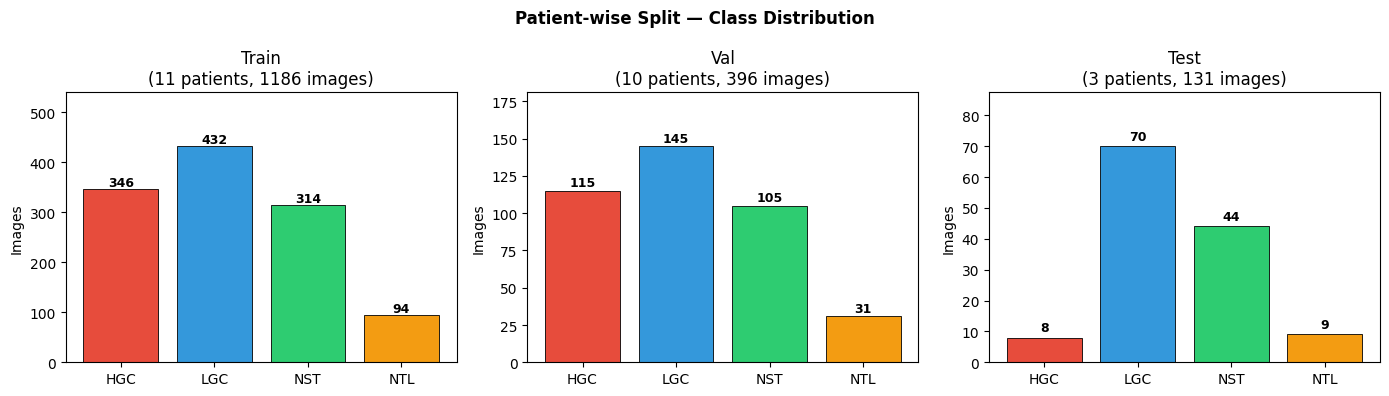


Done. Upload all files from /kaggle/working/ as a Kaggle dataset.
Then add that dataset as input to Notebooks 1, 2, and 3.


In [8]:
# ============================================================
# STEP 7: QUICK VISUAL SANITY CHECK
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Patient-wise Split — Class Distribution',
             fontsize=12, fontweight='bold')

bar_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for ax, (sname, sdf) in zip(axes, [('Train', train_df),
                                     ('Val',   val_df),
                                     ('Test',  test_df)]):
    counts = [len(sdf[sdf[TISSUE_COL] == cls]) for cls in CLASS_NAMES]
    bars   = ax.bar(CLASS_NAMES, counts, color=bar_colors,
                    edgecolor='black', linewidth=0.6)
    n_pats = sdf[PATIENT_COL].nunique()
    ax.set_title(f"{sname}\n({n_pats} patients, {len(sdf)} images)")
    ax.set_ylabel("Images")
    ax.set_ylim(0, max(counts) * 1.25 if max(counts) > 0 else 10)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                str(count), ha='center', va='bottom',
                fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'split_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("\nDone. Upload all files from /kaggle/working/ as a Kaggle dataset.")
print("Then add that dataset as input to Notebooks 1, 2, and 3.")

In [9]:
# ============================================================
# FINAL DUPLICATE & LEAKAGE CHECK
# ============================================================

# Load all CSVs
csv_files = {
    "train":  os.path.join(output_dir, "train.csv"),
    "val":    os.path.join(output_dir, "valid.csv"),
    "test":   os.path.join(output_dir, "test.csv"),
    "full":   os.path.join(output_dir, "full_dataset_with_splits.csv")
}

dfs = {name: pd.read_csv(path) for name, path in csv_files.items()}

print("\n==============================")
print("1️⃣ Duplicate image paths inside each split")
print("==============================")

for name, df in dfs.items():
    dup_paths = df[df.duplicated('full_path', keep=False)]
    print(f"{name.upper()}: {len(dup_paths)} duplicate rows")

print("\n==============================")
print("2️⃣ Cross-split overlap check")
print("==============================")

train_paths = set(dfs['train']['full_path'])
val_paths   = set(dfs['val']['full_path'])
test_paths  = set(dfs['test']['full_path'])

print("Train ∩ Val  :", len(train_paths & val_paths))
print("Train ∩ Test :", len(train_paths & test_paths))
print("Val   ∩ Test :", len(val_paths & test_paths))

print("\n==============================")
print("3️⃣ Duplicate filenames (ignoring folder)")
print("==============================")

for name, df in dfs.items():
    df['filename_only'] = df['full_path'].apply(lambda x: os.path.basename(x))
    dup_names = df[df.duplicated('filename_only', keep=False)]
    print(f"{name.upper()}: {len(dup_names)} duplicate filenames")

print("\n==============================")
print("4️⃣ Global duplicate image check")
print("==============================")

all_paths = pd.concat([
    dfs['train']['full_path'],
    dfs['val']['full_path'],
    dfs['test']['full_path']
])

global_dups = all_paths[all_paths.duplicated()]
print("Global duplicate paths across splits:", len(global_dups))

if len(global_dups) == 0:
    print("\n✅ No image duplication or leakage detected.")
else:
    print("\n⚠ WARNING: Duplicate images detected!")


1️⃣ Duplicate image paths inside each split
TRAIN: 0 duplicate rows
VAL: 0 duplicate rows
TEST: 0 duplicate rows
FULL: 0 duplicate rows

2️⃣ Cross-split overlap check
Train ∩ Val  : 0
Train ∩ Test : 0
Val   ∩ Test : 0

3️⃣ Duplicate filenames (ignoring folder)
TRAIN: 0 duplicate filenames
VAL: 0 duplicate filenames
TEST: 0 duplicate filenames
FULL: 0 duplicate filenames

4️⃣ Global duplicate image check
Global duplicate paths across splits: 0

✅ No image duplication or leakage detected.
